# Orientation, phase, and strain mapping of a two-phase titanium alloy

This capstone notebook combines everything so far: on a single 4D-STEM dataset of a two-phase **titanium alloy**, we will map the crystal **orientation**, identify the local **phase**, and measure the **strain** — the trio of measurements that make nanobeam 4D-STEM such a complete microstructural probe.

**The material.** Titanium alloys contain two phases: **α-Ti** (hexagonal close-packed) and **β-Ti** (body-centered cubic). Their arrangement — lath structures, retained β between α plates — controls the alloy's mechanical properties. Because the two phases have different crystal structures, their diffraction patterns differ, and we can tell them apart pattern by pattern.

**The plan:** detect disks → calibrate (pixel size against the known α-Ti lattice) → run ACOM *twice*, once per candidate phase → decide the phase at each position by which crystal explains the pattern better → compute strain from the residual distortion between measured and best-fit simulated patterns.

The dataset comes from [Ophus et al., J. Microscopy (2024)](https://doi.org/10.1111/jmi.13275) (original data: [doi:10.5525/gla.researchdata.1514](https://doi.org/10.5525/gla.researchdata.1514)), binned and reduced for tutorial speed.

*Prerequisites: the basics and orientation notebooks.*

---

## Tutorial data

The notebook downloads its data automatically. Direct links:

* [Ti550_005_downsampled.h5 dataset](https://drive.google.com/file/d/1ASIrVm4DOr_S_UkTq-t-a8xKZVK3Y4qx/view)
* [α-Ti (hcp) CIF file](https://drive.google.com/file/d/1fCdjtZ_hsjAqRvLTr4rAnEwRSRBh4W5_/view)
* [β-Ti (bcc) CIF file](https://drive.google.com/file/d/1rSNfab0NuO8ZlONFw1tU8lmXUZudFAc-/view)

### Acknowledgements

This tutorial was created by the py4DSTEM instructor team:
Ben Savitzky, Steve Zeltmann, Stephanie Ribet (sribet@lbl.gov), Alex Rakowski, and Colin Ophus (cophus@stanford.edu).

### Running this notebook

This notebook is designed for **Google Colab** — every cell also runs in a local Jupyter session with py4DSTEM installed. Run the cells top to bottom; each section explains what it does and why before the code.

# Set up the environment

In [1]:
# Install py4DSTEM and pymatgen (crystal structures). On Google Colab this
# takes a few minutes -- start it now and read ahead while you wait!
# %pip install -q git+https://github.com/cophus/py4DSTEM.git@dev pymatgen anywidget
# (once the numpy-2 fix is merged upstream, this becomes:
%pip install -q git+https://github.com/py4dstem/py4DSTEM.git@dev pymatgen anywidget

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.8/272.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.9/302.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.9/369.9 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62

If Colab shows a message asking you to **restart the session** after the installation finishes, do so (*Runtime → Restart session*) and then continue from the imports cell below — the installed packages are kept.

In [2]:
import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt

# Colab ships matplotlib < 3.11, whose mathtext calls pyparsing's deprecated
# camelCase API and floods plot output with deprecation messages. Rebind the
# deprecated aliases to the snake_case API so those code paths never run.
# (py4DSTEM dev does this on import; this cell covers older installs.)
import matplotlib, pyparsing
if getattr(matplotlib, "__version_info__", (99,)) < (3, 11):
    def _parse_string_compat(self, instring, parseAll=False, *, parse_all=None):
        return self.parse_string(
            instring, parse_all=parseAll if parse_all is None else parse_all
        )
    pyparsing.ParserElement.parseString = _parse_string_compat
    pyparsing.ParserElement.resetCache = classmethod(lambda c: c.reset_cache())

print('py4DSTEM version:', py4DSTEM.__version__)

py4DSTEM version: 0.14.19


# Download the data

Three files: the 4D-STEM dataset, and **CIF files** (Crystallographic Information Files — the standard text format for crystal structures) for the two candidate phases. py4DSTEM builds its simulation crystals directly from CIFs via pymatgen.

In [3]:
import os

dirpath = '/content/'
file_data = dirpath + 'Ti550_005_downsampled.h5'
cif_Ti_alpha = dirpath + 'Ti_hcp.cif'
cif_Ti_beta = dirpath + 'Ti_bcc.cif'
file_analysis = dirpath + 'Ti550_analysis_'

downloads = [
    ('https://drive.google.com/uc?id=1ASIrVm4DOr_S_UkTq-t-a8xKZVK3Y4qx', 'Ti550_005_downsampled.h5'),
    ('https://drive.google.com/uc?id=1fCdjtZ_hsjAqRvLTr4rAnEwRSRBh4W5_', 'Ti_hcp.cif'),
    ('https://drive.google.com/uc?id=1rSNfab0NuO8ZlONFw1tU8lmXUZudFAc-', 'Ti_bcc.cif'),
]
for id_, name in downloads:
    if not os.path.exists(dirpath + name):
        py4DSTEM.io.gdrive_download(
            id_ = id_,
            destination = dirpath,
            filename = name,
            overwrite = True,
        )

Downloading...
From (original): https://drive.google.com/uc?id=1ASIrVm4DOr_S_UkTq-t-a8xKZVK3Y4qx
From (redirected): https://drive.google.com/uc?id=1ASIrVm4DOr_S_UkTq-t-a8xKZVK3Y4qx&confirm=t&uuid=54178a76-41df-4b55-bd70-1d04366fe9cb
To: /content/Ti550_005_downsampled.h5
100%|██████████| 313M/313M [00:03<00:00, 86.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fCdjtZ_hsjAqRvLTr4rAnEwRSRBh4W5_
To: /content/Ti_hcp.cif
100%|██████████| 1.20k/1.20k [00:00<00:00, 1.57MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rSNfab0NuO8ZlONFw1tU8lmXUZudFAc-
To: /content/Ti_bcc.cif
100%|██████████| 2.95k/2.95k [00:00<00:00, 9.34MB/s]


# Load the data and set pixel calibrations

In [4]:
dataset = py4DSTEM.read(file_data)

In [5]:
# apply the pixel size calibrations from the microscope metadata
pixel_size_inv_Ang = 0.003629 * 8   # diffraction pixels (data was binned 8x)
probe_step_size_Ang = 30.0          # real-space probe step

dataset.calibration.set_Q_pixel_size(pixel_size_inv_Ang)
dataset.calibration.set_Q_pixel_units('A^-1')
dataset.calibration.set_R_pixel_size(probe_step_size_Ang)
dataset.calibration.set_R_pixel_units('A')

dataset

DataCube( A 4-dimensional array of shape (100, 191, 64, 64) called 'datacube',
          with dimensions:

              Rx = [0.0,30.0,60.0,...] A
              Ry = [0.0,30.0,60.0,...] A
              Qx = [0.0,0.029032,0.058064,...] A^-1
              Qy = [0.0,0.029032,0.058064,...] A^-1
)

# Examine the data

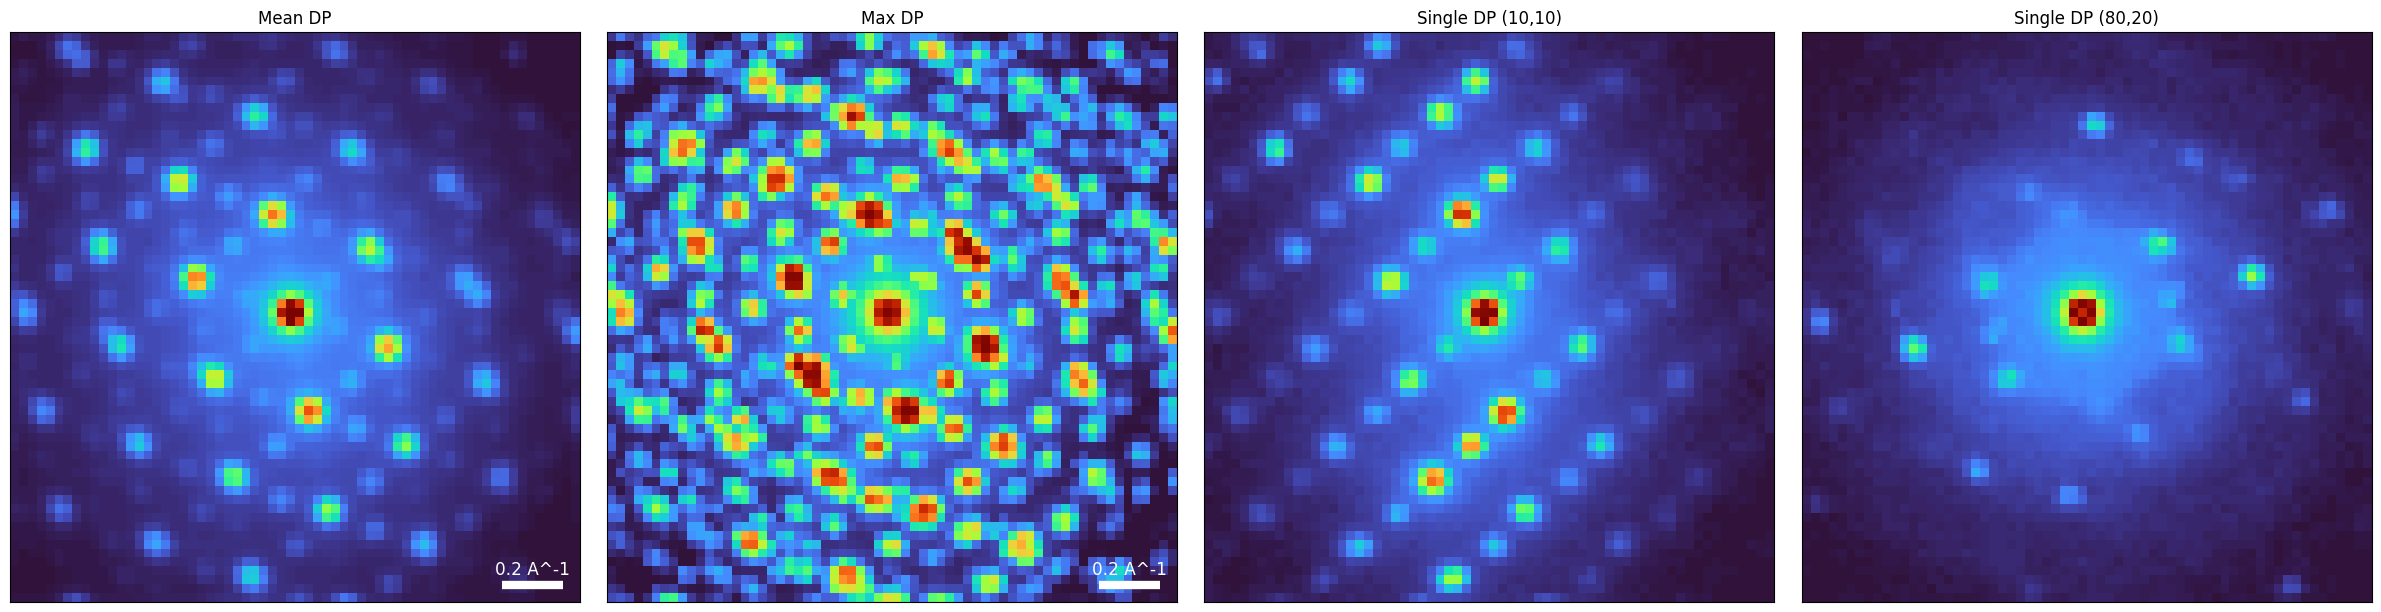

In [6]:
dataset.get_dp_max();
dataset.get_dp_mean();

py4DSTEM.show(
    [
        dataset.tree('dp_mean'),
        dataset.tree('dp_max'),
        dataset.data[10, 10],
        dataset.data[80, 20],
    ],
    vmax = 1,
    power = 0.5,
    cmap = 'turbo',
    ticks = False,
    title = ['Mean DP', 'Max DP', 'Single DP (10,10)', 'Single DP (80,20)'],
)

## Browse the data interactively

Before running any analysis, it is *always* worth exploring a 4D-STEM dataset by hand. The cell below downloads a small interactive browser widget: **click or drag on the left (real-space) panel to move the electron probe**, and the right panel shows the diffraction pattern recorded at that position.

Each panel has its own contrast controls: the small histogram below the image shows the distribution of displayed intensities — **drag the two blue markers** to set the display window (it defaults to the 2%–98% intensity quantiles) — and the **power slider** compresses the dynamic range (diffraction spans many orders of magnitude, so powers well below 1 are usually best on the right panel).

Browsing builds intuition fast: where the sample is, how strongly it diffracts, whether the patterns shift on the detector, and what artifacts to look out for.

In [7]:
# Download the interactive 4D-STEM data browser widget.
import os, sys

if not os.path.exists('/content/browse_4dstem.py'):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c',
        destination = '/content/',
        filename = 'browse_4dstem.py',
    )
sys.path.append('/content')

# on Colab, third-party widgets need the custom widget manager enabled
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass   # not on Colab

from browse_4dstem import browse_4dstem

Downloading...
From (original): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c
From (redirected): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c&confirm=t&uuid=784cce4f-ad82-416e-b889-d715c0dc9b2b
To: /content/browse_4dstem.py
100%|██████████| 17.1k/17.1k [00:00<00:00, 35.8MB/s]


In [8]:
browse_4dstem(dataset.data, power=0.4)

As you browse, notice how sharply the patterns change between neighboring lath regions — different orientations and, in places, a different *phase*.

# Virtual imaging

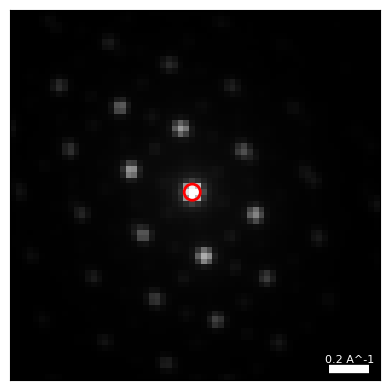

In [9]:
# estimate the direct beam position and size from the mean pattern
probe_semiangle, probe_qx0, probe_qy0 = dataset.get_probe_size(
    dataset.tree('dp_mean').data,
    thresh_lower = 0.5,
)
center = (probe_qx0, probe_qy0)

py4DSTEM.show(
    dataset.tree('dp_mean'),
    figsize = (4, 4),
    circle = {
        'center': center,
        'R': probe_semiangle,
    },
    ticks = False,
    vmax = 1,
)

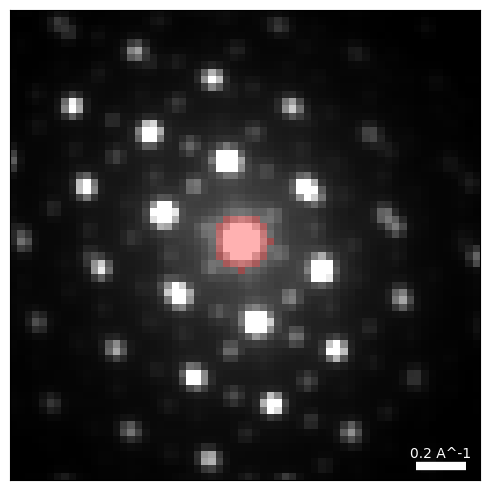

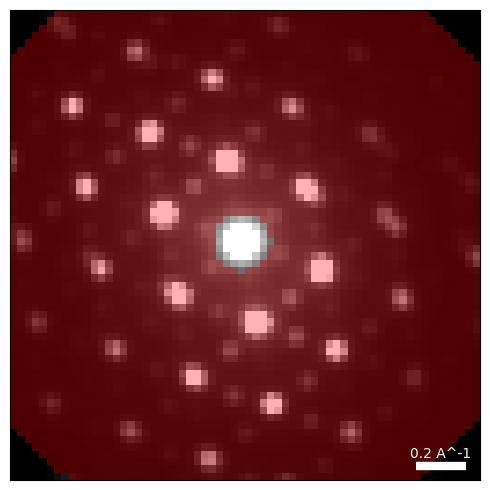

In [10]:
radius_BF = 4
radii_ADF = (4, 40)

dataset.position_detector(
    mode = 'circular',
    geometry = (center, radius_BF),
    ticks = False,
)
dataset.position_detector(
    mode = 'annular',
    geometry = (center, radii_ADF),
    ticks = False,
)

100%|██████████| 19100/19100 [00:00<00:00, 65627.70it/s]


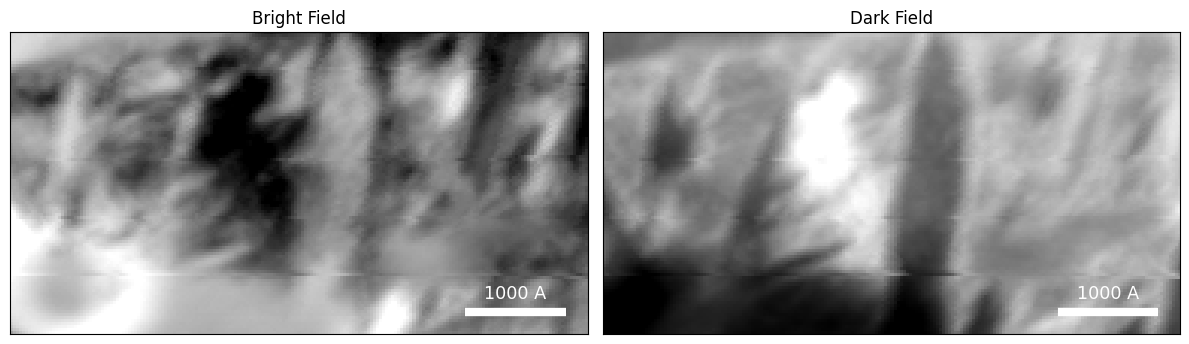

In [11]:
dataset.get_virtual_image(
    mode = 'circular',
    geometry = (center, radius_BF),
    name = 'bright_field',
);
dataset.get_virtual_image(
    mode = 'annular',
    geometry = (center, radii_ADF),
    name = 'dark_field',
);

py4DSTEM.show(
    [
        dataset.tree('bright_field'),
        dataset.tree('dark_field'),
    ],
    ticks = False,
    title = ['Bright Field', 'Dark Field'],
)

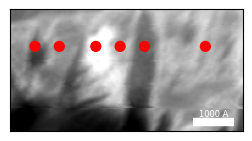

In [12]:
# probe positions we will use for parameter testing
rx = 30, 30, 30, 30, 30, 30
ry = 20, 40, 70, 90, 110, 160
colors = ['r'] * 6

py4DSTEM.visualize.show_points(
    dataset.tree('dark_field'),
    x = rx, y = ry,
    pointcolor = colors,
    figsize = (3, 4),
    ticks = False,
)

# Bragg disk detection

No vacuum probe was recorded with this dataset — so we build a **synthetic probe template** instead: an ideal disk with the same radius as the direct beam. A synthetic template works well when the disks are small and clean, as here; a measured vacuum probe is still preferred when you have one (see the orientation notebook).

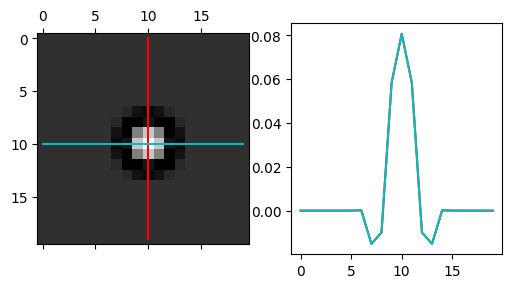

In [13]:
radius = 1.5
width = 1.5

probe_kernel = py4DSTEM.Probe.get_probe_kernel_edge_sigmoid(
    py4DSTEM.Probe.generate_synthetic_probe(
        radius,
        width,
        dataset.Qshape,
    ),
    radii = (2, 4.0),
)

py4DSTEM.visualize.show_kernel(
    probe_kernel,
    R = 10, L = 10, W = 1,
    figsize = (6, 3),
)

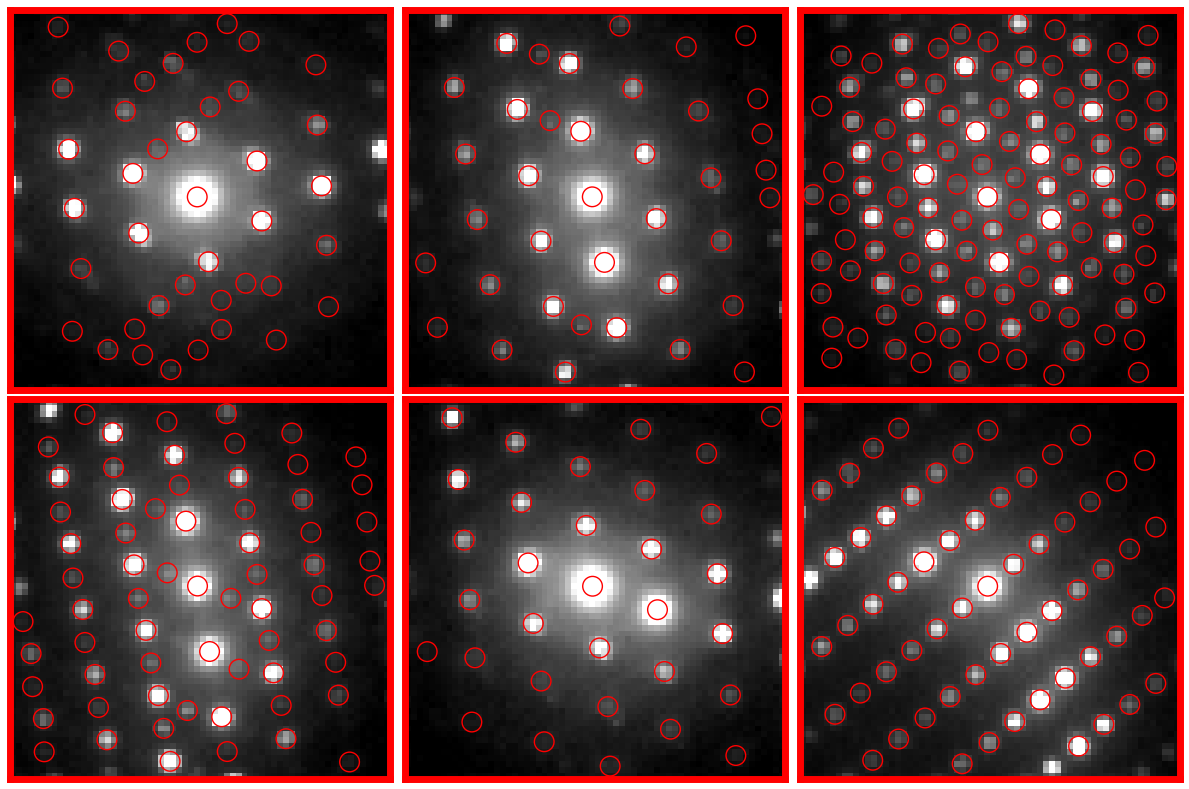

In [14]:
# test the detection parameters on the sample positions
detect_params = {
    'corrPower': 1.0,
    'sigma': 0,
    'edgeBoundary': 2,
    'minRelativeIntensity': 0,
    'minAbsoluteIntensity': 36.0,
    'minPeakSpacing': 4,
    'subpixel': 'poly',    # ACOM does not need high-precision positions
    'maxNumPeaks': 500,
}

disks_selected = dataset.find_Bragg_disks(
    data = (rx, ry),
    template = probe_kernel,
    **detect_params,
)

py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i: dataset.data[rx[i], ry[i], :, :],
    H = 2, W = 3,
    axsize = (4, 4),
    power = 0.5,
    get_bordercolor = lambda i: colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 200,
)

In [15]:
# detect in every pattern
bragg_peaks = dataset.find_Bragg_disks(
    template = probe_kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 19.1k/19.1k [00:34<00:00, 551DP/s]


In [16]:
# checkpoint
file_braggdisks_raw = file_analysis + 'braggdisks_raw.h5'
py4DSTEM.save(
    file_braggdisks_raw,
    bragg_peaks,
    mode = 'o',
)

# If you restart the session, you can inspect and reload the checkpoint:
# py4DSTEM.print_h5_tree(file_braggdisks_raw)
# bragg_peaks = py4DSTEM.read(
#     file_braggdisks_raw,
# )


100%|██████████| 19100/19100 [00:03<00:00, 5343.65it/s]


# Calibration

## Centering

We measure the pattern origin at every position and fit a plane, exactly as in the strain notebook. The `'intensity'` scoring works here because the direct beam is the brightest peak in (almost) every pattern:

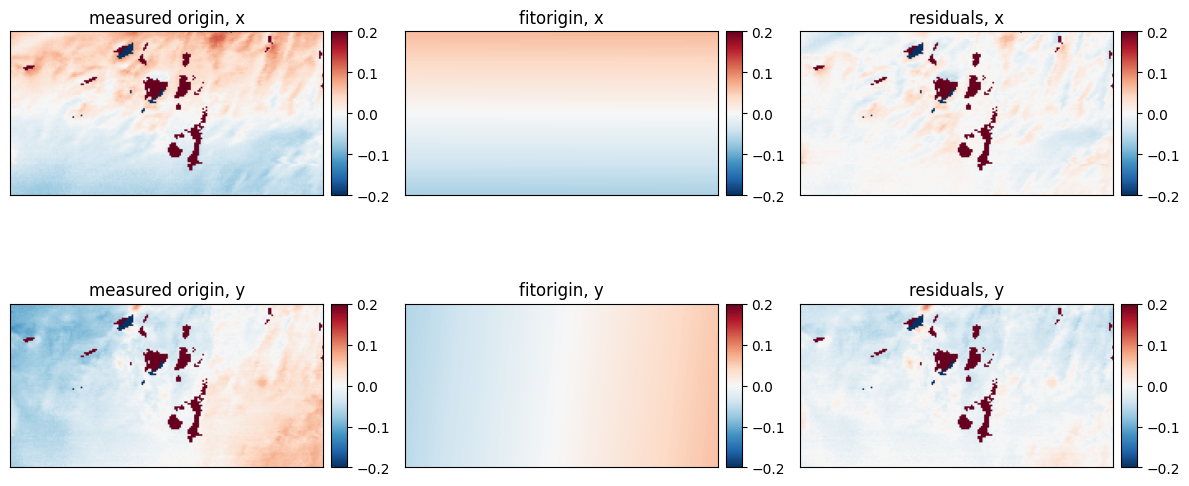

In [17]:
origin_meas = bragg_peaks.measure_origin(
    center_guess = center,
    score_method = 'intensity',
)

qx0_fit, qy0_fit, qx0_residuals, qy0_residuals = bragg_peaks.fit_origin(
    robust = True,
    plot_range = 0.2,
    ticks = False,
    axsize = (4, 4),
)

# note the plot range: +/- 0.2 pixels. This dataset has very little descan!

## Ellipticity and rotation

This dataset was already corrected for elliptical distortion, and its rotation is zero — so we simply record identity calibrations. (On your own data, never skip measuring these — see the strain notebook for how.)

In [18]:
bragg_peaks.calibration.set_ellipse((1, 1, 0))
bragg_peaks.calibration.set_QR_rotation_degrees(0)
bragg_peaks.calibration.set_QR_flip(False)

## Pixel size — calibrated against α-Ti

As in the orientation notebook, we refine the diffraction pixel size against a known lattice — here the α-Ti structure loaded from its CIF. Most of the scan is α phase, so its rings dominate the measured peaks:

In [19]:
inv_Ang_per_pixel = 0.039   # initial guess

bragg_peaks.calibration.set_Q_pixel_size(inv_Ang_per_pixel)
bragg_peaks.calibration.set_Q_pixel_units('A^-1')
bragg_peaks.calibrate()

In [20]:
crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(cif_Ti_alpha)

k_max = 1.6
crystal.calculate_structure_factors(k_max)

get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.


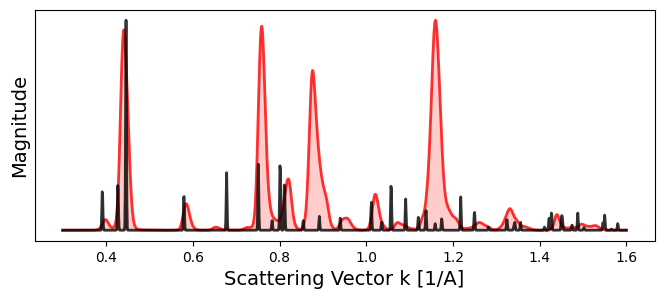

In [21]:
# compare measured scattering with the predicted alpha-Ti rings
plot_params = {
    'bragg_peaks': bragg_peaks,
    'k_power_scale': 0.0,
    'k_broadening': 0.001,
    'bragg_k_power': 2.0,
    'bragg_k_broadening': 0.005,
    'k_min': 0.3,
    'figsize': (8, 3),
}

crystal.plot_scattering_intensity(**plot_params)

Calibrated pixel size = 0.03864414 A^-1


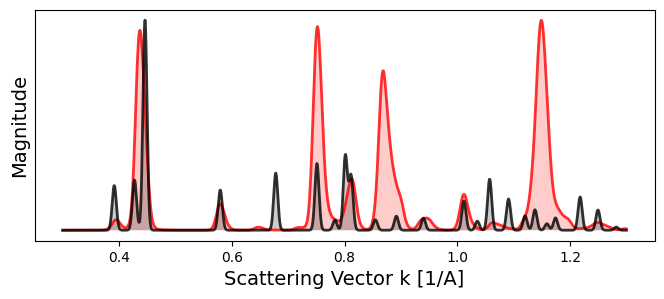

In [22]:
bragg_peaks_calibrated = crystal.calibrate_pixel_size(
    bragg_peaks = bragg_peaks,
    bragg_k_power = 2.0,
    k_min = 0.3,
    k_max = 1.3,
    k_step = 0.001,
    k_broadening = 0.002,
    plot_result = True,
    fit_all_intensities = False,
    figsize = (8, 3),
)

In [23]:
# checkpoint
file_braggdisks_cali = file_analysis + 'braggdisks_calibrated.h5'
py4DSTEM.save(
    file_braggdisks_cali,
    bragg_peaks_calibrated,
    mode = 'o',
)

# If you restart the session, you can inspect and reload the checkpoint:
# py4DSTEM.print_h5_tree(file_braggdisks_cali)
# bragg_peaks_calibrated = py4DSTEM.read(
#     file_braggdisks_cali,
# )


100%|██████████| 19100/19100 [00:04<00:00, 4584.70it/s]


# Orientation mapping — two candidate phases

Now we build *two* crystals — α (hcp) and β (bcc) — and an orientation plan for each. Every pattern will be matched against both dictionaries; later, the comparison of match quality tells us the phase.

To keep the tutorial fast we use a coarse orientation search with local refinement (`angle_coarse_zone_axis` + `angle_refine_range`); for production analysis you would tighten these.

In [24]:
crystal_Ti_alpha = py4DSTEM.process.diffraction.Crystal.from_CIF(cif_Ti_alpha)
crystal_Ti_beta = py4DSTEM.process.diffraction.Crystal.from_CIF(cif_Ti_beta)

k_max = 1.4   # reduced from 1.6 to speed up the tutorial
crystal_Ti_alpha.calculate_structure_factors(k_max)
crystal_Ti_beta.calculate_structure_factors(k_max)

get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.


In [25]:
acom_params = {
    'zone_axis_range': 'auto',
    'angle_step_zone_axis': 2.5,
    'angle_coarse_zone_axis': 5.0,
    'angle_refine_range': 3.0,
    'angle_step_in_plane': 10.0,
    'accel_voltage': 200e3,
    'corr_kernel_size': 0.04,
    'power_intensity': 0.5,
    'power_intensity_experiment': 0.5,
}

crystal_Ti_alpha.orientation_plan(**acom_params)
crystal_Ti_beta.orientation_plan(**acom_params)

Automatically detected point group 6/mmm,
 using arguments: zone_axis_range = 
[[0.8660254 0.5       0.       ]
 [1.        0.        0.       ]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 703/703 [00:00<00:00, 12173.41 zone axes/s]


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 276/276 [00:00<00:00, 12696.77 zone axes/s]


## Test on single patterns

Check the matching at a couple of positions before running the full map. For each position we fit both crystals, then *generate* the diffraction patterns predicted by the two best-fit orientations of each phase and overlay them on the measured pattern (grey crosses). The four panels are: α match 0, α match 1, β match 0, β match 1 — the correct phase and orientation is the panel whose predicted peaks land on the measured ones.

Seeing the matches as you look at different probe positions is essential — try the other `xind, yind` values in the comments to compare an α position against a β position:


Best fit lattice directions: z axis = ([ 0.655 -0.311 -0.344  0.   ]), x axis = ([ 0.142 -0.005 -0.137  0.951]), with corr value = 263.818
Best fit lattice directions: z axis = ([ 0.464 -0.028 -0.436  0.157]), x axis = ([ 0.621 -0.272 -0.349  0.23 ]), with corr value = 101.361
Best fit lattice directions: z axis = ([0.531 0.599 0.599]), x axis = ([0.174 0.615 0.769]), with corr value = 296.241
Best fit lattice directions: z axis = ([0.09  0.404 0.91 ]), x axis = ([0.284 0.366 0.886]), with corr value = 73.24


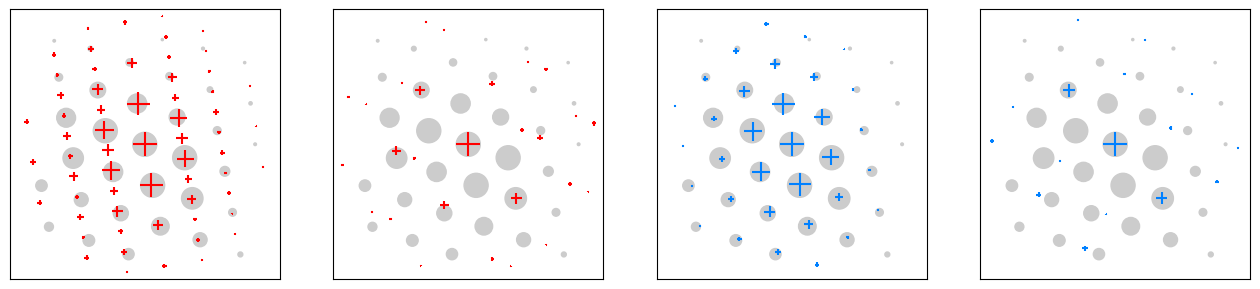

In [26]:
# Test orientation_matching matching on some probe positions

xind, yind = 50,130
# xind, yind = 50,150
# xind, yind = 50,180
# xind, yind = 30,121

min_angle_between_matches_deg = 30
precession_angle_degrees = 0.5
sigma_compare = 0.02
num_matches_return = 2


# Fit all crystals
orientation_Ti_alpha  = crystal_Ti_alpha.match_single_pattern(
    bragg_peaks_calibrated.cal[xind,yind],
    num_matches_return = num_matches_return,
    verbose = True,
    min_angle_between_matches_deg=min_angle_between_matches_deg,
)
orientation_Ti_beta  = crystal_Ti_beta.match_single_pattern(
    bragg_peaks_calibrated.cal[xind,yind],
    num_matches_return = num_matches_return,
    verbose = True,
    min_angle_between_matches_deg=min_angle_between_matches_deg,
)


# Generate test diffraction patterns for matches 0 and 1
bragg_peaks_fit_Ti_alpha_0 = crystal_Ti_alpha.generate_diffraction_pattern(
    orientation_Ti_alpha,
    ind_orientation=0,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)
bragg_peaks_fit_Ti_alpha_1 = crystal_Ti_alpha.generate_diffraction_pattern(
    orientation_Ti_alpha,
    ind_orientation=1,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)

bragg_peaks_fit_Ti_beta_0 = crystal_Ti_beta.generate_diffraction_pattern(
    orientation_Ti_beta,
    ind_orientation=0,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)
bragg_peaks_fit_Ti_beta_1 = crystal_Ti_beta.generate_diffraction_pattern(
    orientation_Ti_beta,
    ind_orientation=1,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)


# plotting frame
figsize = (4,4)
fig,ax = plt.subplots(1,4,figsize=(4*figsize[0],1*figsize[1]))

plot_params = {
    'bragg_peaks_compare':     bragg_peaks_calibrated.cal[xind,yind],
    # 'plot_range_kx_ky':  np.array([k_max,k_max]),
    'plot_range_kx_ky':  np.array([1.4,1.4]),
    'min_marker_size': 1,
    'max_marker_size': 300,
    'add_labels': False,

    'scale_markers': 8000,
    'scale_markers_compare': 0.02,
    'marker': '+',
    'facecolor_compare': (0.8,0.8,0.8),

    # 'color':(1,0,0),
    'edgecolor': None,
    # 'facecolor': 'none',
    'linewidth':1.5,
    'show_axes':False
}


# plot comparisons
# Ti alpha
py4DSTEM.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ti_alpha_0,
    input_fig_handle=(fig,[ax[0]]),
    color = (1.0,0.0,0.0),
    **plot_params,
)
py4DSTEM.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ti_alpha_1,
    input_fig_handle=(fig,[ax[1]]),
    color = (1.0,0.0,0.0),
    **plot_params,
)
# Ti beta
py4DSTEM.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ti_beta_0,
    input_fig_handle=(fig,[ax[2]]),
    color = (0.0,0.5,1.0),
    **plot_params,
)
py4DSTEM.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ti_beta_1,
    input_fig_handle=(fig,[ax[3]]),
    color = (0.0,0.5,1.0),
    **plot_params,
)

## Match all positions with both crystals

Two full ACOM runs — this is the longest computation of the notebook (several minutes each):

In [27]:
num_matches_return = 1
min_angle_between_matches_deg = 30

orientation_map_Ti_alpha = crystal_Ti_alpha.match_orientations(
    bragg_peaks_calibrated,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)
orientation_map_Ti_beta = crystal_Ti_beta.match_orientations(
    bragg_peaks_calibrated,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)

Matching Orientations: 100%|██████████| 19100/19100 [00:40<00:00, 470.87 PointList/s]


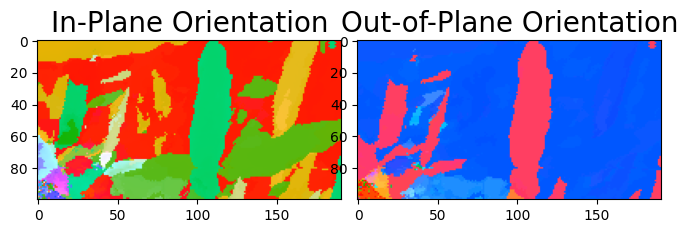

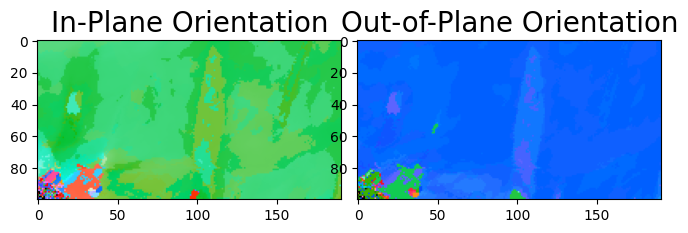

In [28]:
# orientation maps for both phases
c_r = (0, 0.01)

im_alpha = crystal_Ti_alpha.plot_orientation_maps(
    orientation_map = crystal_Ti_alpha.orientation_map,
    corr_range = c_r,
    figsize = (8, 4),
    show_legend = False,
);
im_beta = crystal_Ti_beta.plot_orientation_maps(
    orientation_map = crystal_Ti_beta.orientation_map,
    corr_range = c_r,
    figsize = (8, 4),
    show_legend = False,
);

Each map colors *every* position — including positions that are really the other phase (where the fit is poor). A first, crude phase estimate: at each position, which crystal correlated better?

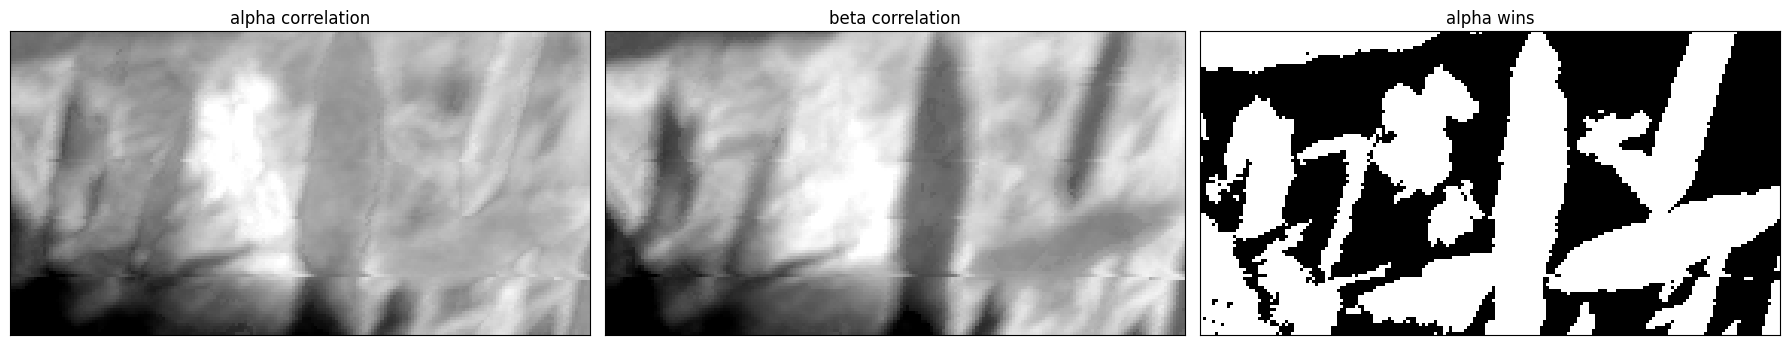

In [29]:
phase_alpha = crystal_Ti_alpha.orientation_map.corr[:, :, 0] > \
              crystal_Ti_beta.orientation_map.corr[:, :, 0]

py4DSTEM.show(
    [
        crystal_Ti_alpha.orientation_map.corr[:, :, 0],
        crystal_Ti_beta.orientation_map.corr[:, :, 0],
        phase_alpha,
    ],
    ticks = False,
    title = ['alpha correlation', 'beta correlation', 'alpha wins'],
)

# Phase mapping

`CrystalPhase` does this comparison properly: it re-fits each pattern as a combination of the candidate phases (using the best-fit orientations we just computed), and reports per-position **phase weights** and a **reliability** score — how confidently the pattern distinguishes the phases.

In [30]:
phase_map = py4DSTEM.process.diffraction.CrystalPhase(
    crystals = [crystal_Ti_alpha, crystal_Ti_beta],
    crystal_names = ['Ti_alpha', 'Ti_beta'],
)

phase_weight   or_ind   name
        0.00        0   Ti_alpha    
       31.27        0   Ti_beta     
----------------------------
       31.27       fit total
       38.64    fit residual


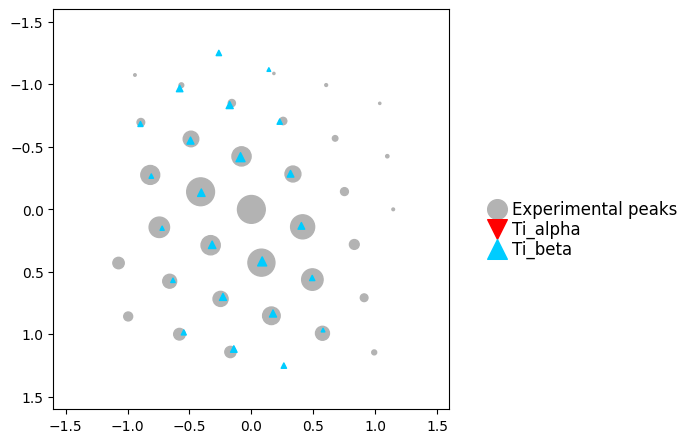

In [31]:
# inspect the phase decision at a single position first
phase_weights, phase_residual, phase_reliability, int_total = phase_map.quantify_single_pattern(
    bragg_peaks_calibrated,
    xy_position = (50, 130),   # try (50, 150) for an alpha position

    single_phase = True,
    max_number_patterns = 1,
    allow_strain = False,

    corr_kernel_size = 0.04,
    sigma_excitation_error = 0.01,
    precession_angle_degrees = 0.5,

    plot_unmatched_peaks = True,
    scale_markers_experiment = 0.02,
    scale_markers_calculated = 100,
    k_max = 1.6,
    figsize = (6, 4),
)

In [32]:
# quantify every position
phase_map.quantify_phase(
    bragg_peaks_calibrated,

    single_phase = True,
    max_number_patterns = 1,
    allow_strain = True,

    corr_kernel_size = 0.04,
    sigma_excitation_error = 0.01,
    precession_angle_degrees = 0.5,

    k_max = 1.6,
)

Quantifying Phase: 100%|██████████| 19100/19100 [01:19<00:00, 241.28 PointList/s]


Phase Fractions
---------------
Ti_alpha - 51.8891%
Ti_beta - 48.1109%


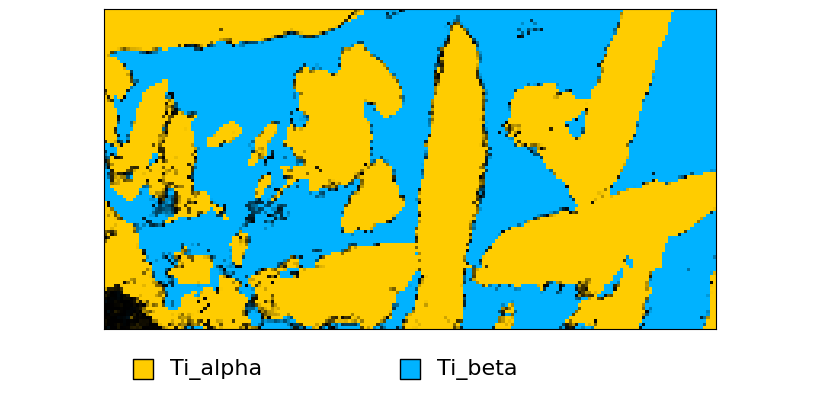

In [33]:
mask_range = (0.0, 1.0)

fig, ax = phase_map.plot_dominant_phase(
    reliability_range = mask_range,
    figsize = (8, 4),
    sigma = 1,
    phase_colors = np.array([
        [1.0, 0.8, 0.0],
        [0.0, 0.7, 1.0],
    ]),
    ticks = False,
    print_fractions = True,
)

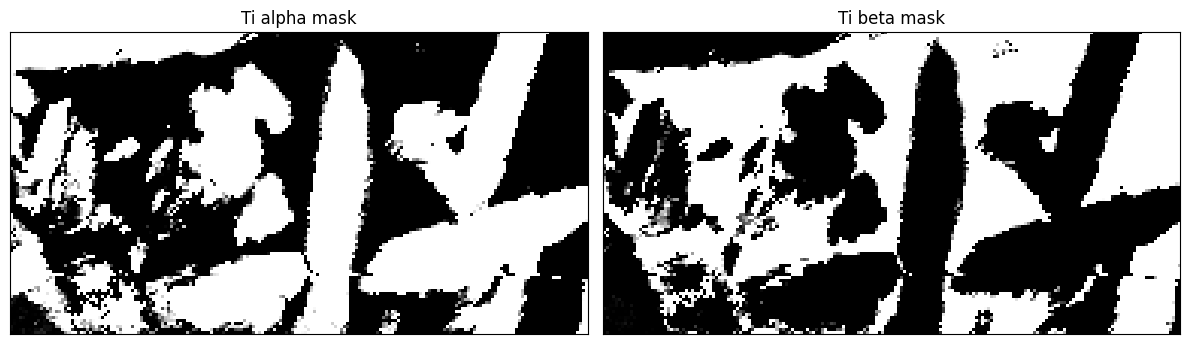

In [34]:
# boolean-ish masks for each phase, weighted by reliability
mask = np.clip(
    (phase_map.phase_reliability - mask_range[0])
    / (mask_range[1] - mask_range[0]), 0, 1)
mask_alpha = mask * (phase_map.phase_weights[:, :, 0] > phase_map.phase_weights[:, :, 1])
mask_beta = mask * (phase_map.phase_weights[:, :, 1] > phase_map.phase_weights[:, :, 0])

py4DSTEM.show(
    [mask_alpha, mask_beta],
    ticks = False,
    title = ['Ti alpha mask', 'Ti beta mask'],
)

# Strain mapping from ACOM

A bonus of orientation matching: for every position we now have both the *measured* disk positions and the *simulated* pattern of the best-fit orientation. The distortion that maps one onto the other is the **strain tensor** — so we get strain maps for each phase without choosing lattice vectors by hand:

In [35]:
strain_map_Ti_alpha = crystal_Ti_alpha.calculate_strain(
    bragg_peaks,
    orientation_map_Ti_alpha,
    rotation_range = 2 * np.pi,
)
strain_map_Ti_beta = crystal_Ti_beta.calculate_strain(
    bragg_peaks,
    orientation_map_Ti_beta,
    rotation_range = 2 * np.pi,
)

Calculating strains: 100%|██████████| 19100/19100 [00:22<00:00, 843.21 PointList/s] 


'oneOf' deprecated - use 'one_of'
'oneOf' deprecated - use 'one_of'
'leaveWhitespace' deprecated - use 'leave_whitespace'
'oneOf' deprecated - use 'one_of'
'oneOf' deprecated - use 'one_of'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse_action'
'setName' deprecated - use 'set_name'
'setParseAction' deprecated - use 'set_parse

Ti alpha phase


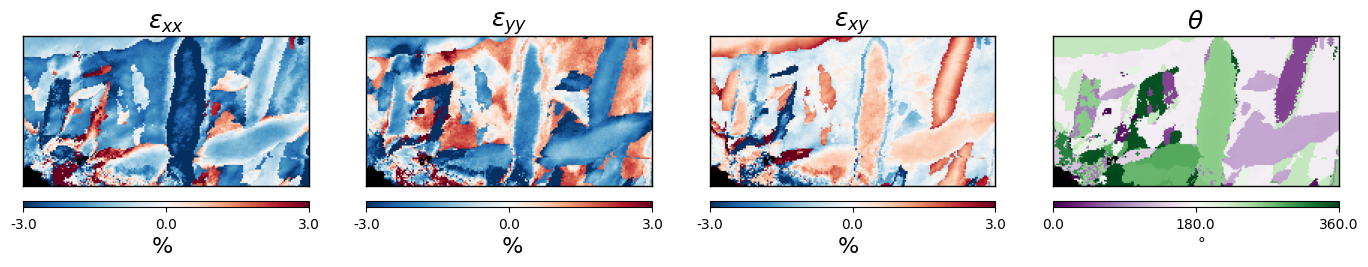

In [36]:
print('Ti alpha phase')
fig, ax = py4DSTEM.visualize.show_strain(
    strain_map_Ti_alpha,
    vrange_exx = [-3.0, 3.0],
    vrange_theta = [0.0, 360.0],
    ticknumber = 3,
    figsize = (12, 6),
    layout = 'horizontal',
    returnfig = True,
)

Ti beta phase


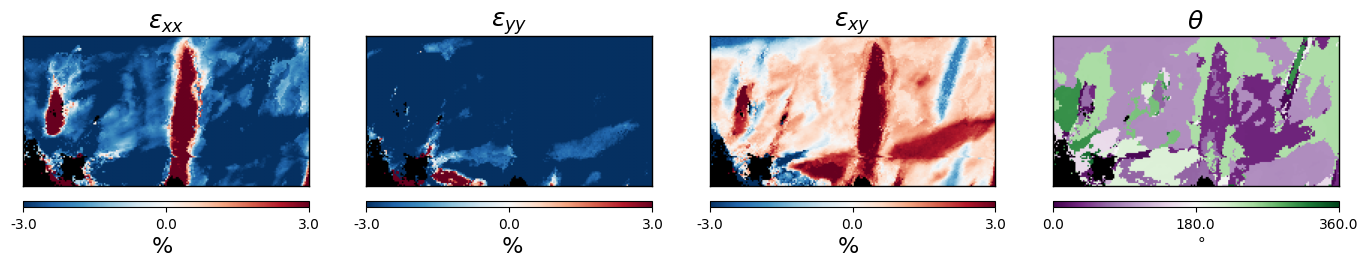

In [37]:
print('Ti beta phase')
fig, ax = py4DSTEM.visualize.show_strain(
    strain_map_Ti_beta,
    vrange_exx = [-3.0, 3.0],
    vrange_theta = [0.0, 360.0],
    ticknumber = 3,
    figsize = (12, 6),
    layout = 'horizontal',
    returnfig = True,
)

# Putting it together: masked maps

Each per-phase map is only meaningful *where that phase actually is* — so as a final step, we apply the phase masks to the orientation maps, and build a combined dilatational-strain image:

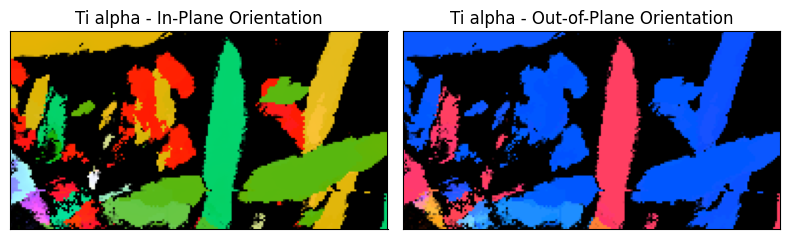

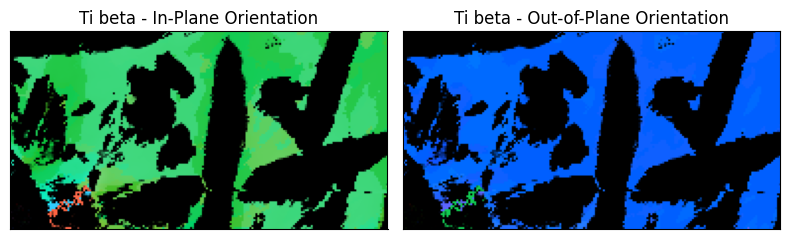

In [38]:
py4DSTEM.show(
    [
        im_alpha[:, :, :, 0] * mask_alpha[:, :, None],
        im_alpha[:, :, :, 1] * mask_alpha[:, :, None],
    ],
    axsize = (4, 2.5),
    ticks = False,
    title = ['Ti alpha - In-Plane Orientation', 'Ti alpha - Out-of-Plane Orientation'],
)
py4DSTEM.show(
    [
        im_beta[:, :, :, 0] * mask_beta[:, :, None],
        im_beta[:, :, :, 1] * mask_beta[:, :, None],
    ],
    axsize = (4, 2.5),
    ticks = False,
    title = ['Ti beta - In-Plane Orientation', 'Ti beta - Out-of-Plane Orientation'],
)

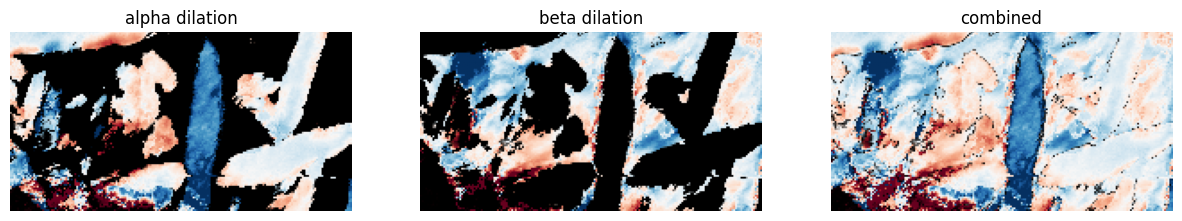

In [39]:
import matplotlib.cm as cm

# dilatational strain (e_xx + e_yy) per phase, referenced to each phase's mean
strain_alpha = \
    strain_map_Ti_alpha.get_slice('e_xx').data + \
    strain_map_Ti_alpha.get_slice('e_yy').data
strain_beta = \
    strain_map_Ti_beta.get_slice('e_xx').data + \
    strain_map_Ti_beta.get_slice('e_yy').data
strain_alpha -= np.sum(strain_alpha * mask_alpha) / np.sum(mask_alpha)
strain_beta -= np.sum(strain_beta * mask_beta) / np.sum(mask_beta)

# color and combine
vmin, vmax = -0.03, 0.03
norm = plt.Normalize(vmin, vmax)
cmap = cm.RdBu_r

strain_alpha_rgb = cmap(norm(strain_alpha))[..., :3] * mask_alpha[..., None]
strain_beta_rgb = cmap(norm(strain_beta))[..., :3] * mask_beta[..., None]
rgb_image = np.clip(strain_alpha_rgb + strain_beta_rgb, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(strain_alpha_rgb); ax[0].set_title('alpha dilation')
ax[1].imshow(strain_beta_rgb); ax[1].set_title('beta dilation')
ax[2].imshow(rgb_image); ax[2].set_title('combined')
for a in ax:
    a.axis('off')
plt.show()

# Recap and things to try

One dataset, three measurements: orientation (per-phase ACOM), phase (comparative pattern fitting with reliability), and strain (distortion between measured and simulated patterns) — all built on the same detected Bragg disks.

Some experiments to try:

- Tighten the orientation search (`angle_step_zone_axis = 1.0`, `angle_step_in_plane = 5.0`) and compare the maps — what improved, and what did it cost in time?
- In `quantify_single_pattern`, move `xy_position` around a lath boundary and watch the phase weights and reliability change.
- Set `allow_strain = False` in `quantify_phase` — how does the phase map change near strained boundaries?